# CE Efficiency ($\alpha_{\rm CE}$) Investigation

Companion analysis to the *Lower Your Rates* compilation, focused on the
common-envelope efficiency parameter $\alpha_{\rm CE}$ in **isolated binary
evolution** population-synthesis studies.

This notebook addresses two questions:

1. **What $\alpha_{\rm CE}$ values do studies actually use?** — the range per
   study, and the distribution of values by population-synthesis code and by
   compact-object (DCO) type.
2. **How does varying $\alpha_{\rm CE}$ change the merger rate?** — the BBH /
   BHNS / BNS rate as a function of $\alpha_{\rm CE}$.

**Data** (`../data/`): `isolated-binary-evolution_relationships.csv` (single-
parameter variations) and `isolated-binary-evolution.csv` (the simulation
catalog). We keep **only** isolated-binary-evolution relationships with
`parameter_family == "common envelope efficiency (alpha_CE)"`.

In [1]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import LogLocator, MultipleLocator
from itertools import cycle
import seaborn as sns

# ── paths ──────────────────────────────────────────────────────────────────────
DATA_DIR = Path("../data")
FIG_DIR  = Path("../figures")
FIG_DIR.mkdir(exist_ok=True)

# ── plotting style (no usetex, so this runs anywhere) ──────────────────────────
plt.rcParams.update({
    "figure.dpi":      110,
    "font.size":       12,
    "axes.titlesize":  13,
    "axes.labelsize":  13,
    "axes.linewidth":  1.2,
    "savefig.bbox":    "tight",
})
ALPHA_TEX = r"$\alpha_{\mathrm{CE}}$"

# ── constants ──────────────────────────────────────────────────────────────────
ALPHA_FAMILY = "common envelope efficiency (alpha_CE)"
DCO_TYPES    = ["BH-BH", "NS-BH", "NS-NS"]
DCO_LABEL    = {"BH-BH": "BBH", "NS-BH": "BHNS", "NS-NS": "BNS"}
DCO_COLORS   = {"BH-BH": "#d1a13a", "NS-BH": "#3b82c4", "NS-NS": "#b5468f"}

# ── load ───────────────────────────────────────────────────────────────────────
rels = pd.read_csv(DATA_DIR / "isolated-binary-evolution_relationships.csv")
sims = pd.read_csv(DATA_DIR / "isolated-binary-evolution.csv")
print(f"relationships: {len(rels)} rows | simulation catalog: {len(sims)} rows")

relationships: 7943 rows | simulation catalog: 4532 rows


In [2]:
def parse_alpha(s):
    """Extract a numeric alpha_CE value from the assorted string encodings used
    in the catalog, e.g. '0.5', '10', 'alpha_CE=0.1', 'alpha_CE=1 (fiducial)',
    'a=1'. Returns NaN for non-alpha entries (e.g. 'Eq9') or missing values."""
    if pd.isna(s):
        return np.nan
    s = str(s).strip()
    if "eq" in s.lower():                 # 'Eq9' is an equation ref, not an alpha
        return np.nan
    s = s.replace("alpha_CE", "").replace("α", "")   # strip 'alpha_CE' / Greek alpha
    m = re.search(r"[-+]?\d*\.?\d+", s)
    return float(m.group()) if m else np.nan

# keep only alpha_CE relationships and parse alpha + rates
alpha = rels[rels["parameter_family"] == ALPHA_FAMILY].copy()
alpha["from_alpha"] = alpha["from_value"].apply(parse_alpha)
alpha["to_alpha"]   = alpha["to_value"].apply(parse_alpha)
alpha["from_rate"]  = pd.to_numeric(alpha["from_rate_Gpc3yr"], errors="coerce")
alpha["to_rate"]    = pd.to_numeric(alpha["to_rate_Gpc3yr"],   errors="coerce")

print(f"alpha_CE relationships: {len(alpha)} rows | "
      f"{alpha['study_key'].nunique()} studies | "
      f"{alpha['code'].nunique()} codes | "
      f"DCO types: {sorted(alpha['compact_object_type'].dropna().unique())}")

alpha_CE relationships: 749 rows | 27 studies | 8 codes | DCO types: ['BH-BH', 'NS-BH', 'NS-NS']


In [3]:
# Tidy long table: one row per (study, DCO type, distinct alpha value used).
recs = []
for (study, dco), g in alpha.groupby(["study_key", "compact_object_type"]):
    vals = pd.unique(np.concatenate([g["from_alpha"].values, g["to_alpha"].values]))
    vals = np.sort([v for v in vals if np.isfinite(v)])
    code_name = g["code"].dropna().iloc[0]  if g["code"].notna().any()  else "unknown"
    label     = g["label"].dropna().iloc[0] if g["label"].notna().any() else study
    for v in vals:
        recs.append(dict(study_key=study, label=label, code=code_name,
                         compact_object_type=dco, alpha=v))
alpha_long = pd.DataFrame(recs)

studies = sorted(alpha_long["study_key"].unique())
print(f"{len(studies)} studies contribute numeric alpha values")

# rainbow colour per study (husl), matching the violin-plot palette; used in
# the rate-vs-alpha plots
_study_cols = sns.color_palette("husl", n_colors=len(studies))
study_color = {s: _study_cols[i] for i, s in enumerate(studies)}
alpha_long.head()

25 studies contribute numeric alpha values


,study_key,label,code,compact_object_type,alpha
0,Ablimit_2018_BSE,Ablimit and Maeda (2018),BSE,BH-BH,1.0
1,Ablimit_2018_BSE,Ablimit and Maeda (2018),BSE,NS-BH,1.0
2,Ablimit_2018_BSE,Ablimit and Maeda (2018),BSE,NS-NS,1.0
3,ArcaSedda_2026_BPop,Arca Sedda et al. (2026),B-POP,BH-BH,1.0
4,ArcaSedda_2026_BPop,Arca Sedda et al. (2026),B-POP,BH-BH,5.0


## 1 · Range of $\alpha_{\rm CE}$ explored per study

Each study occupies one row; the horizontal line spans the min–max range of
$\alpha_{\rm CE}$ it explores, with a marker at every distinct value used.
Studies are grouped/coloured by population-synthesis code. (The $\alpha_{\rm CE}$
grid is the same across a study's DCO types, so one line per study.)

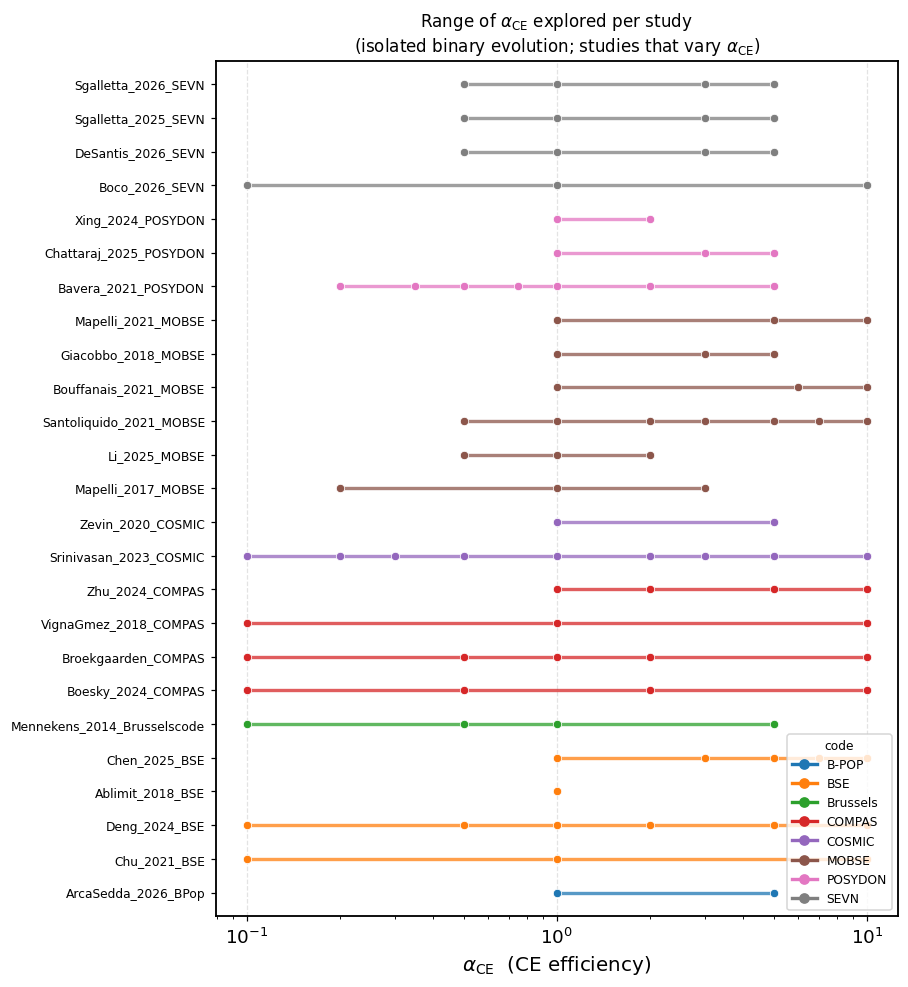

In [4]:
# per-study alpha grid (union over DCO types)
grid = (alpha_long.groupby(["study_key", "code"])["alpha"]
        .apply(lambda x: np.sort(x.unique()))
        .reset_index())
grid["amin"] = grid["alpha"].apply(min)
grid["amax"] = grid["alpha"].apply(max)
grid = grid.sort_values(["code", "amin", "study_key"]).reset_index(drop=True)

codes_sorted = sorted(grid["code"].unique())
code_cmap = {c: plt.get_cmap("tab10")(i) for i, c in enumerate(codes_sorted)}

fig, ax = plt.subplots(figsize=(8, 0.34 * len(grid) + 1.6))
for y, row in grid.iterrows():
    vals = row["alpha"]; c = code_cmap[row["code"]]
    ax.plot([row["amin"], row["amax"]], [y, y], color=c, lw=2.2, alpha=0.75, zorder=2)
    ax.scatter(vals, [y] * len(vals), color=c, s=30, zorder=3,
               edgecolors="white", linewidths=0.5)

ax.set_yticks(range(len(grid)))
ax.set_yticklabels(grid["study_key"], fontsize=8)
ax.set_ylim(-0.7, len(grid) - 0.3)
ax.set_xscale("log")
ax.set_xlabel(ALPHA_TEX + "  (CE efficiency)")
ax.set_title("Range of " + ALPHA_TEX + " explored per study\n"
             "(isolated binary evolution; studies that vary " + ALPHA_TEX + ")",
             fontsize=11)
ax.grid(axis="x", ls="--", alpha=0.35)
handles = [Line2D([], [], color=code_cmap[c], lw=2.2, marker="o", label=c)
           for c in codes_sorted]
ax.legend(handles=handles, title="code", fontsize=8, title_fontsize=8,
          loc="lower right")
fig.savefig(FIG_DIR / "alpha_range_per_study.png", dpi=180)
plt.show()

## 2 · Distribution of $\alpha_{\rm CE}$ values

Violin (KDE + quartiles) and cumulative-distribution (CDF) views of the
$\alpha_{\rm CE}$ values used, split **by population-synthesis code** and
**by compact-object type**. Each sample is a distinct $\alpha_{\rm CE}$ value
used by a study (deduplicated per study so a study with a finer grid does not
dominate disproportionately within a group).

In [10]:
def cdf_violin_alpha(data, group_col, suptitle, fname,
                     min_points=1, ref_alpha=1.0, xmin=-1, xmax=1):
    """Two-panel distribution plot in the *Lower Your Rates* style, for alpha_CE.

    Top panel    : CDFs of alpha per group (+ combined "All"), log x-axis.
    Bottom panel : half-violins of log10(alpha) with jittered scatter points,
                   a median diamond, a min-max whisker, and an inline label.
    Groups are ordered by median alpha (ascending); colours are a rainbow (husl)
    palette. A dotted reference line marks the fiducial alpha = 1.
    """
    d = data.copy()
    d = d[np.isfinite(d["alpha"]) & (d["alpha"] > 0)]

    counts = d[group_col].value_counts()
    groups = counts[counts >= min_points].index.tolist()
    order  = (d[d[group_col].isin(groups)].groupby(group_col)["alpha"]
              .median().sort_values().index.tolist())

    colors = sns.color_palette("husl", n_colors=len(order))   # rainbow
    g2c    = dict(zip(order, colors))
    lss    = ["-", "--", "-.", ":", (0, (1, 1)), (0, (5, 1)),
              (0, (3, 1, 1, 1)), (0, (5, 2, 1, 2))]
    g2ls   = {g: ls for g, ls in zip(order, cycle(lss))}

    fig_h = max(5.0, 0.72 * len(order) + 2.4)
    fig, (ax_cdf, ax) = plt.subplots(
        2, 1, figsize=(8.0, fig_h), sharex=False,
        gridspec_kw={"height_ratios": [1.0, 2.5], "hspace": 0.08})
    rng = np.random.default_rng(42)

    # ── Top panel: CDFs in raw alpha space, shown on a log x-axis ──
    for g in order:
        vals = np.sort(d.loc[d[group_col] == g, "alpha"].values)
        cdf  = np.arange(1, len(vals) + 1) / len(vals)
        ax_cdf.plot(vals, cdf, lw=2.0, color=g2c[g], linestyle=g2ls[g],
                    alpha=0.9, label=f"{g} ({len(vals)})")
    allv = np.sort(d["alpha"].values)
    ax_cdf.plot(allv, np.arange(1, len(allv) + 1) / len(allv),
                lw=2.6, color="black", alpha=0.95, zorder=1,
                label=f"All ({len(allv)})")
    ax_cdf.axvline(ref_alpha, color="0.5", ls=":", lw=1.2, zorder=0)

    ax_cdf.set_xscale("log")
    ax_cdf.set_xlim(10**xmin, 10**xmax)
    ax_cdf.xaxis.set_major_locator(LogLocator(base=10))
    ax_cdf.xaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10)))
    ax_cdf.set_ylim(0, 1.02)
    ax_cdf.set_ylabel("CDF", fontsize=13, fontweight="bold")
    ax_cdf.yaxis.set_major_locator(MultipleLocator(0.2))
    ax_cdf.yaxis.set_minor_locator(MultipleLocator(0.1))
    ax_cdf.tick_params(labelbottom=False)
    ax_cdf.legend(loc="upper left", frameon=False, fontsize=9.5,
                  ncol=2 if len(order) > 4 else 1)

    # ── Bottom panel: half-violins + scatter in log10(alpha) space ──
    for i, g in enumerate(order):
        vals = d.loc[d[group_col] == g, "alpha"].values
        x = np.log10(vals)
        color = g2c[g]

        if len(x) >= 3:
            parts = ax.violinplot([x], positions=[i], vert=False, widths=0.72,
                                  showmeans=False, showmedians=False,
                                  showextrema=False)
            for body in parts["bodies"]:
                body.set_facecolor(color); body.set_edgecolor(color)
                body.set_alpha(0.28); body.set_zorder(1)
                v = body.get_paths()[0].vertices
                v[:, 1] = np.maximum(v[:, 1], i)      # keep upper half only

        jitter = rng.uniform(-0.18, -0.04, len(x))
        ax.scatter(x, i + jitter, s=16, alpha=0.78, color=color,
                   edgecolor="white", linewidth=0.35, zorder=3)
        mx = np.median(x)
        ax.scatter(mx, i, marker="d", s=58, facecolor=color,
                   edgecolor="black", linewidth=0.6, zorder=4)
        ax.plot([np.min(x), np.max(x)], [i, i], lw=1.2, color=color,
                alpha=0.75, zorder=2)
        ax.text(np.max(x) + 0.06, i + 0.22, f"{g} ({len(x)})", color=color,
                fontsize=11, fontweight="bold", va="center", ha="left")

    ax.axvline(np.log10(ref_alpha), color="0.5", ls=":", lw=1.2, zorder=1)
    ax.set_yticks(np.arange(len(order)))
    ax.set_yticklabels([""] * len(order))
    ax.set_ylim(-0.6, len(order) - 0.35)
    ax.set_xlim(xmin - 0.35, xmax + 0.6)

    major = np.arange(xmin, xmax + 1)
    ax.set_xticks(major)
    ax.set_xticklabels([rf"$10^{{{int(t)}}}$" for t in major])
    minor = []
    for dec in range(xmin, xmax):
        minor.extend(dec + np.log10(np.arange(2, 10)))
    ax.set_xticks(minor, minor=True)
    ax.set_xlabel(ALPHA_TEX + "  (CE efficiency)", fontsize=15)
    ax.yaxis.set_minor_locator(MultipleLocator(0.5))

    for axis in (ax_cdf, ax):
        axis.grid(which="major", axis="both", alpha=0.35)
        axis.grid(which="minor", axis="both", alpha=0.15)
        axis.tick_params(axis="both", which="major", length=7, width=1.0,
                         labelsize=13)
        axis.tick_params(axis="both", which="minor", length=4.5, width=0.8)

    fig.suptitle(suptitle, fontsize=13, y=0.995)
    plt.tight_layout()
    fig.savefig(FIG_DIR / (fname + ".pdf"), bbox_inches="tight")
    fig.savefig(FIG_DIR / (fname + ".png"), dpi=200, bbox_inches="tight")
    plt.show()

/var/folders/07/v05tmc2s6p1f8qvmc216wrh80000gn/T/ipykernel_12977/2573705131.py:106: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


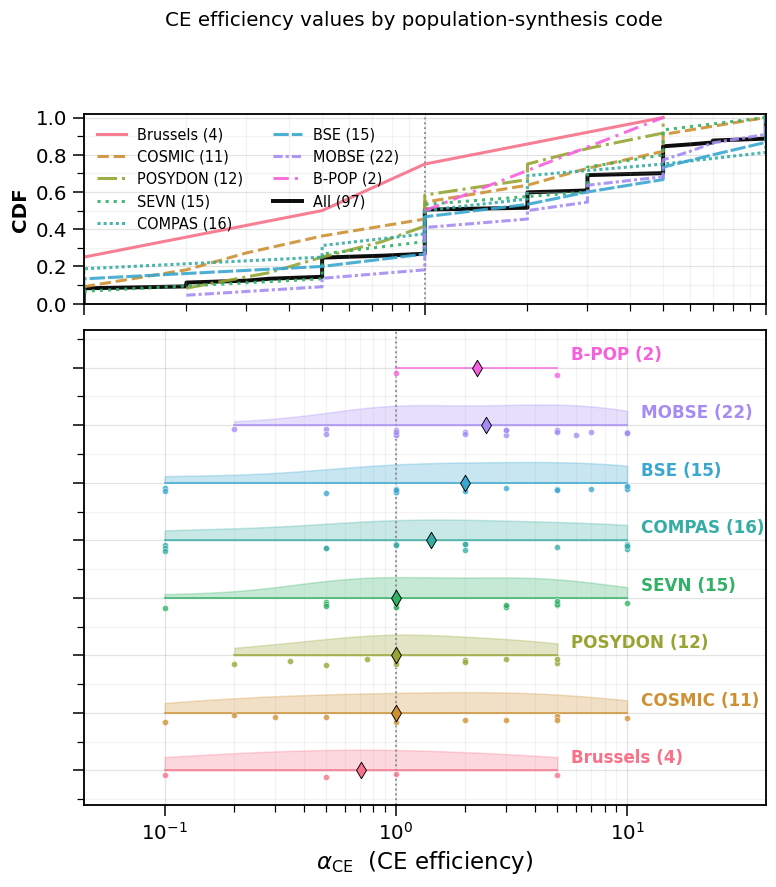

In [11]:
# ── by population-synthesis code ──
by_code = alpha_long.drop_duplicates(["study_key", "code", "alpha"])
cdf_violin_alpha(by_code, "code",
                 "CE efficiency values by population-synthesis code",
                 "alpha_dist_by_code")

/var/folders/07/v05tmc2s6p1f8qvmc216wrh80000gn/T/ipykernel_12977/2573705131.py:106: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


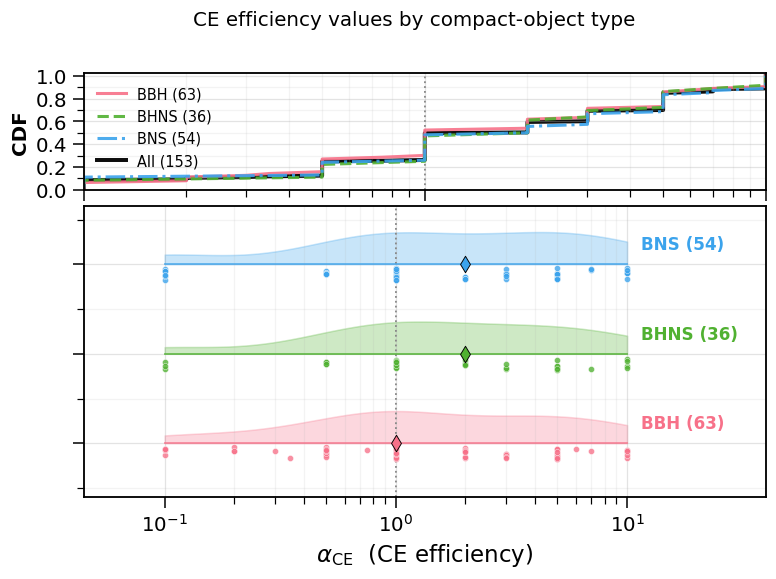

In [12]:
# ── by compact-object type ──
by_dco = alpha_long.drop_duplicates(
    ["study_key", "compact_object_type", "alpha"]).copy()
by_dco["DCO"] = by_dco["compact_object_type"].map(DCO_LABEL)
cdf_violin_alpha(by_dco, "DCO",
                 "CE efficiency values by compact-object type",
                 "alpha_dist_by_dco")

## 3 · Merger rate vs $\alpha_{\rm CE}$

For every alpha_CE relationship we draw a line segment connecting its two
endpoints, $(\alpha_{\rm from},\,R_{\rm from}) \to (\alpha_{\rm to},\,R_{\rm to})$.
Segments from the **same study share a colour**, so chained variations within a
study link up into curves. One panel per DCO type (BBH / BHNS / BNS).

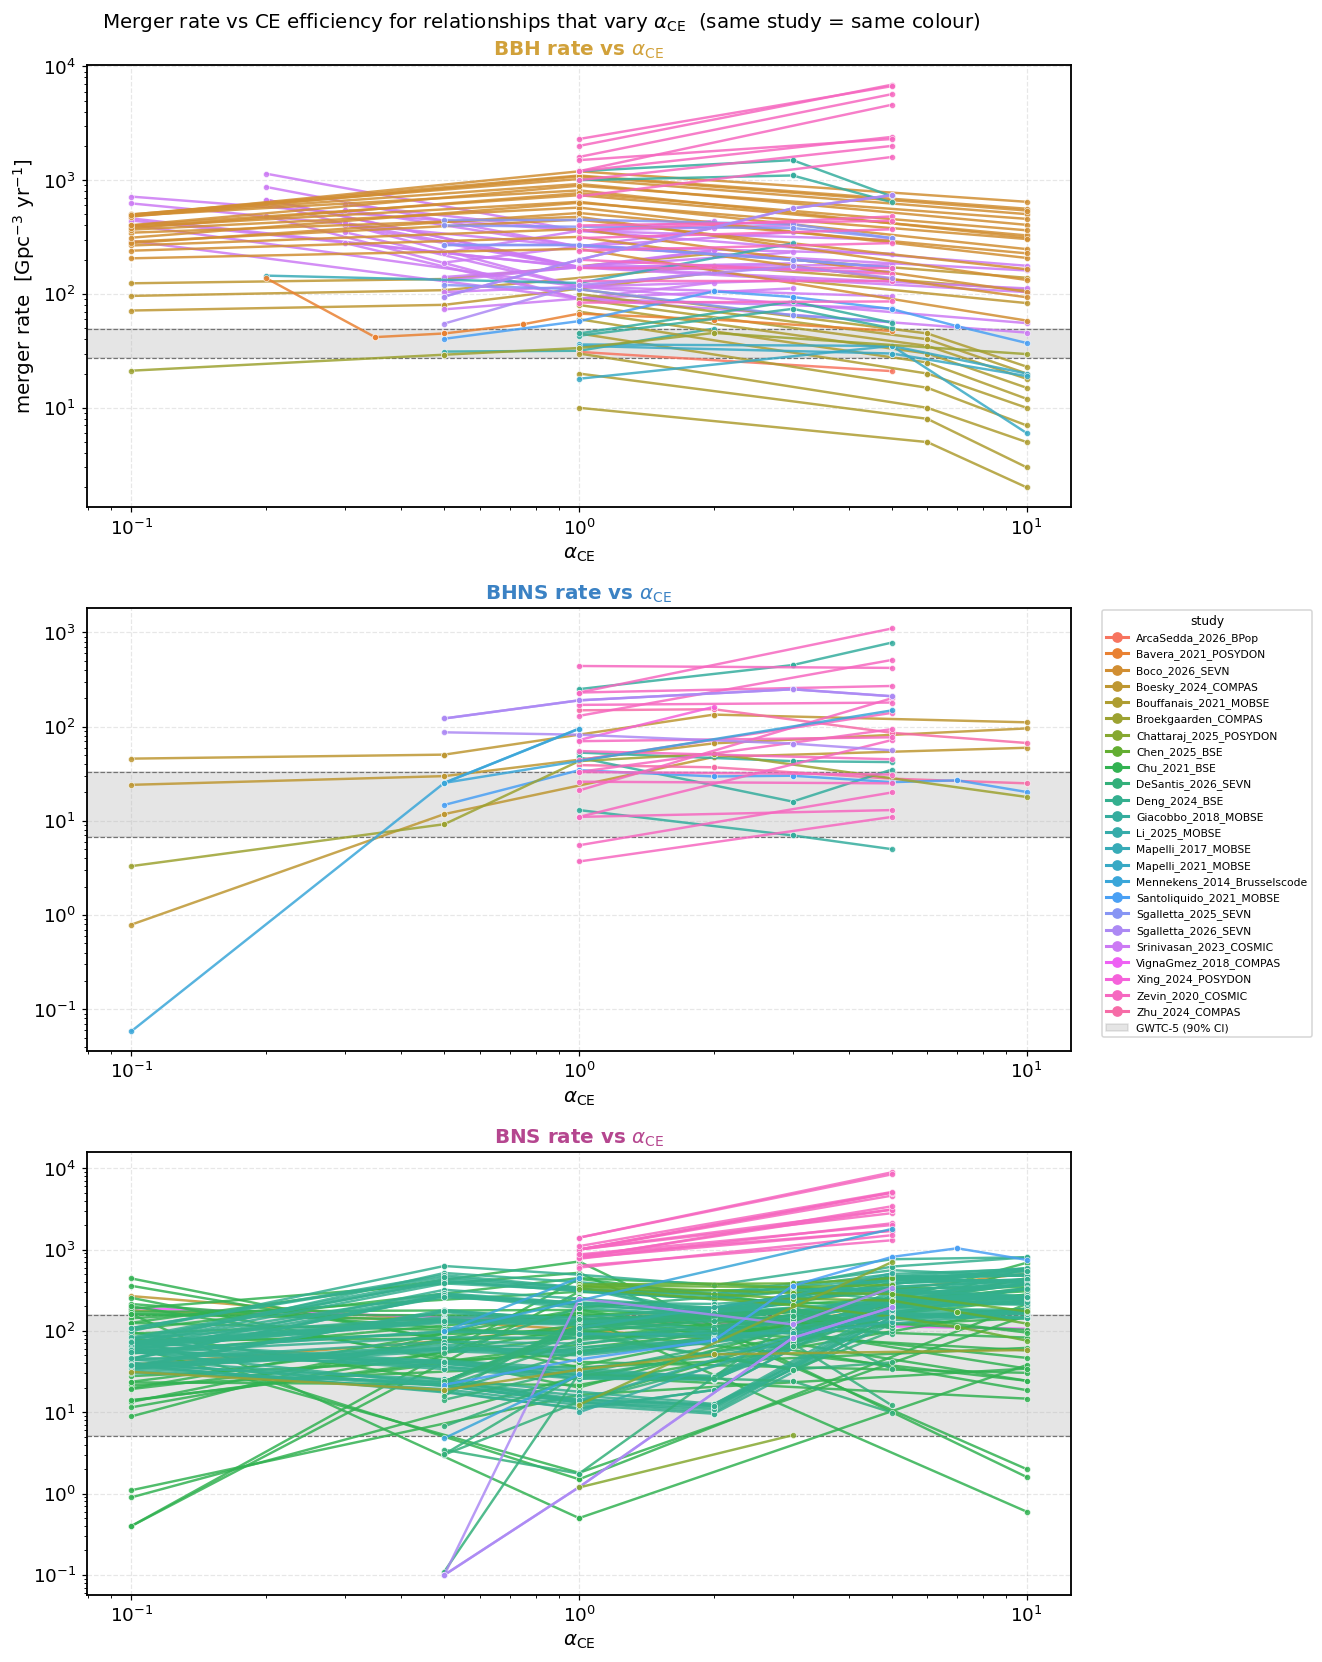

In [8]:
# GWTC-5 observational rate constraints (90% interval), per DCO type
from matplotlib.patches import Patch
_obs = pd.read_csv(DATA_DIR / "observations-GWs.csv")
_g5  = _obs[_obs["study_key"] == "Abbott_2026_GWTC5"]
GWTC5_BANDS = {
    dco: (
        float(_g5[(_g5["compact_object_type"] == dco) &
                  (_g5["rate_type"] == "lower")]["rate_Gpc3yr"].iloc[0]),
        float(_g5[(_g5["compact_object_type"] == dco) &
                  (_g5["rate_type"] == "upper")]["rate_Gpc3yr"].iloc[0]),
    )
    for dco in DCO_TYPES
}

fig, axes = plt.subplots(3, 1, figsize=(10, 15.4), sharey=False)
plotted = {}
for ax, dco in zip(axes, DCO_TYPES):
    # GWTC-5 observational band (drawn behind the model curves)
    lo, hi = GWTC5_BANDS[dco]
    ax.axhspan(lo, hi, color="0.45", alpha=0.18, zorder=0)
    ax.axhline(lo, color="0.45", ls="--", lw=0.8, zorder=0)
    ax.axhline(hi, color="0.45", ls="--", lw=0.8, zorder=0)

    sub = alpha[alpha["compact_object_type"] == dco].dropna(
        subset=["from_alpha", "to_alpha", "from_rate", "to_rate"])
    sub = sub[(sub["from_rate"] > 0) & (sub["to_rate"] > 0)]
    for _, r in sub.iterrows():
        c = study_color[r["study_key"]]
        ax.plot([r["from_alpha"], r["to_alpha"]],
                [r["from_rate"],  r["to_rate"]],
                color=c, lw=1.6, alpha=0.85, marker="o", ms=4,
                markeredgecolor="white", markeredgewidth=0.4, zorder=2)
        plotted[r["study_key"]] = c
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel(ALPHA_TEX)
    ax.set_title(f"{DCO_LABEL[dco]} rate vs " + ALPHA_TEX,
                 color=DCO_COLORS[dco], fontweight="bold")
    ax.grid(ls="--", alpha=0.3)
axes[0].set_ylabel(r"merger rate  [Gpc$^{-3}$ yr$^{-1}$]")

handles = [Line2D([], [], color=plotted[s], lw=2, marker="o", label=s)
           for s in sorted(plotted)]
handles.append(Patch(facecolor="0.45", alpha=0.18, edgecolor="0.45",
                     label="GWTC-5 (90% CI)"))
fig.legend(handles=handles, loc="center left", bbox_to_anchor=(1.005, 0.5),
           fontsize=7, title="study", title_fontsize=8)
fig.suptitle("Merger rate vs CE efficiency for relationships that vary "
             + ALPHA_TEX + "  (same study = same colour)", fontsize=13)
fig.tight_layout()
fig.savefig(FIG_DIR / "rate_vs_alpha_by_dco.png", dpi=180)
plt.show()

### 3b · Merger rate *relative* to the $\alpha_{\rm CE}=1$ submodel

Same as Plot 3, but each $\alpha_{\rm CE}$-variation series is divided by its rate at
$\alpha_{\rm CE}=1$. Series are reconstructed as connected components of the
relationship graph (each edge varies only $\alpha_{\rm CE}$). The reference rate is the
exact $\alpha_{\rm CE}=1$ submodel where it exists, otherwise a log-log interpolation to
$\alpha_{\rm CE}=1$; series whose $\alpha_{\rm CE}$ range excludes 1 are omitted.

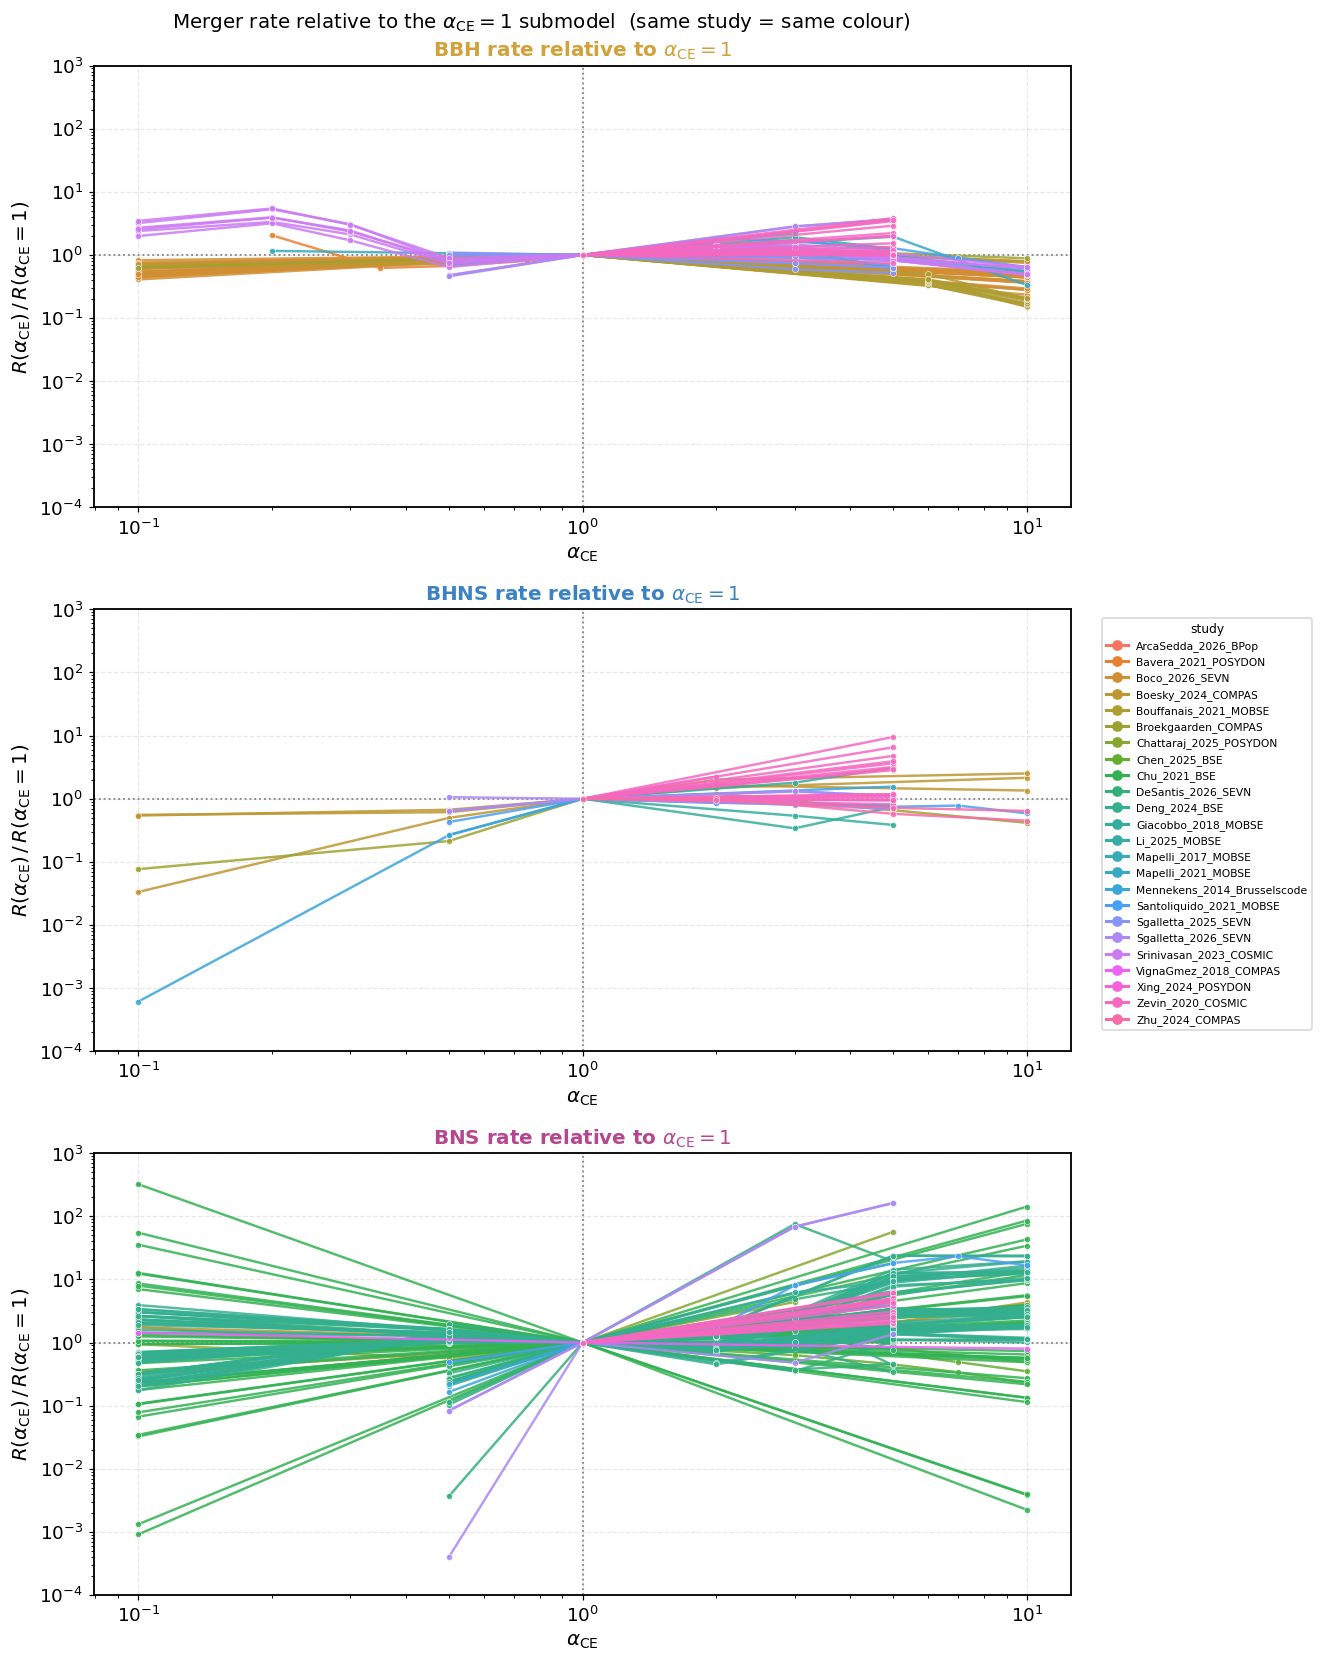

In [14]:
# ── Plot 3b: rate relative to the alpha_CE = 1 submodel ─────────────────────────
def _alpha1_reference(pts):
    """Rate at alpha=1 for a series of (alpha, rate) points: exact if an alpha=1
    submodel exists, else log-log interpolated; NaN if 1 is outside the range."""
    xs = np.array([p[0] for p in pts], float)
    ys = np.array([p[1] for p in pts], float)
    o = np.argsort(xs); xs, ys = xs[o], ys[o]
    hit = np.isclose(xs, 1.0)
    if hit.any():
        return ys[hit][0]
    if xs.min() <= 1.0 <= xs.max():
        return float(np.exp(np.interp(np.log(1.0), np.log(xs), np.log(ys))))
    return np.nan

def _series_for(sub):
    """Reconstruct alpha-variation series within one (study, DCO) group as the
    connected components of the relationship graph (each edge changes only alpha).
    Returns a list of series, each a sorted list of (alpha, rate) points."""
    node, parent = {}, {}
    def find(x):
        while parent[x] != x:
            parent[x] = parent[parent[x]]; x = parent[x]
        return x
    for _, r in sub.iterrows():
        for s, a, rt in ((r["from_submodel"], r["from_alpha"], r["from_rate"]),
                         (r["to_submodel"],   r["to_alpha"],   r["to_rate"])):
            node[s] = (a, rt); parent.setdefault(s, s)
        ra, rb = find(r["from_submodel"]), find(r["to_submodel"])
        if ra != rb:
            parent[ra] = rb
    comps = {}
    for s in node:
        comps.setdefault(find(s), []).append(s)
    return [sorted({node[s] for s in members}) for members in comps.values()]

fig, axes = plt.subplots(3, 1, figsize=(10, 15.4), sharey=False)
plotted = {}
for ax, dco in zip(axes, DCO_TYPES):
    sub = alpha[alpha["compact_object_type"] == dco].dropna(
        subset=["from_alpha", "to_alpha", "from_rate", "to_rate"])
    sub = sub[(sub["from_rate"] > 0) & (sub["to_rate"] > 0)]
    for study, g in sub.groupby("study_key"):
        c = study_color[study]
        for pts in _series_for(g):
            ref = _alpha1_reference(pts)
            if not np.isfinite(ref) or ref <= 0:
                continue
            xs = [p[0] for p in pts]
            ys = [p[1] / ref for p in pts]
            ax.plot(xs, ys, color=c, lw=1.6, alpha=0.85, marker="o", ms=4,
                    markeredgecolor="white", markeredgewidth=0.4, zorder=2)
            plotted[study] = c
    ax.axhline(1.0, color="0.5", ls=":", lw=1.2, zorder=1)
    ax.axvline(1.0, color="0.5", ls=":", lw=1.2, zorder=1)
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel(ALPHA_TEX)
    ax.set_ylabel(r"$R(\alpha_{\mathrm{CE}})\,/\,R(\alpha_{\mathrm{CE}}{=}1)$")
    ax.set_title(f"{DCO_LABEL[dco]} rate relative to " + ALPHA_TEX + r"$=1$",
                 color=DCO_COLORS[dco], fontweight="bold")
    ax.grid(ls="--", alpha=0.3)
    ax.set_ylim(1E-4, 1E3)

handles = [Line2D([], [], color=plotted[s], lw=2, marker="o", label=s)
           for s in sorted(plotted)]
fig.legend(handles=handles, loc="center left", bbox_to_anchor=(1.005, 0.5),
           fontsize=7, title="study", title_fontsize=8)
fig.suptitle("Merger rate relative to the " + ALPHA_TEX + r"$=1$ submodel"
             "  (same study = same colour)", fontsize=13)
fig.tight_layout()
fig.savefig(FIG_DIR / "rate_vs_alpha_relative_by_dco.png", dpi=180)
plt.show()

### Saved figures
- `figures/alpha_range_per_study.png` — Plot 1
- `figures/alpha_dist_by_code.png`, `figures/alpha_dist_by_dco.png` — Plot 2
- `figures/rate_vs_alpha_by_dco.png` — Plot 3